# 17장 실습 — 현장 데이터가 정책을 고치는가

16장의 문을 통과한 정책이 현장에 나갔다. 14장의 게이트가 붙어 있으므로, 위험한 순간마다 대본 제어기가 대신 움직인다. 그 개입 기록이 쌓인다.

**그 기록으로 정책을 고칠 수 있는가.** 문헌은 그렇다고 답한다 — Sirius-Fleet 은 3라운드에 걸쳐 시뮬 +13%, 실기 +45% 를 보고했고, Open X-Embodiment 는 RT-1 을 41% 에서 63% 로 끌어올렸다. HELP 는 운영자 2명으로 로봇 12대를 돌렸다.

이 노트북이 묻는 것은 한 단계 더 좁다. 라벨 예산이 정해져 있을 때 **어느 순간을 라벨할 것인가.** 게이트가 고른 순간이 무작위로 고른 순간보다 값을 하는가.

실행 시간은 CPU에서 8분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (68s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


In [6]:
class AutoEnc(nn.Module):
    def __init__(self, d=8, h=16, z=4):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.Tanh(),
                                 nn.Linear(h, z))
        self.dec = nn.Sequential(nn.Linear(z, h), nn.Tanh(),
                                 nn.Linear(h, d))

    def forward(self, x):
        return self.dec(self.enc(x))


def collect_ok(policy, n=64, steps=400, seed=5):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    seen = [[] for _ in range(n)]
    keep = []
    for t in range(steps):
        o = env.obs()
        for i in range(n):
            seen[i].append(o[i])
        with torch.no_grad():
            a = policy.dist(torch.from_numpy(o)).sample().numpy()
        _, dn, sc = env.step(a)
        k = 0
        for i in range(n):
            if dn[i]:
                if sc[k] > .5:
                    keep += seen[i]
                seen[i] = []
                k += 1
    return torch.from_numpy(np.stack(keep))


def train_ae(X, epochs=200, seed=5):
    torch.manual_seed(seed)
    m = AutoEnc()
    opt = torch.optim.Adam(m.parameters(), 3e-3)
    mu, sd = X.mean(0, keepdim=True), X.std(0, keepdim=True) + 1e-6
    Z = (X - mu) / sd
    n = Z.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 1024):
            j = idx[k:k + 1024]
            loss = ((m(Z[j]) - Z[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m, mu, sd


t0 = time.time()
AE, MU, SD = train_ae(collect_ok(POLICY))
print(f"자동부호기 학습 끝  ({time.time() - t0:.0f}s)")


def gate_signal(ot):
    """12장의 두 신호를 합친 위험도"""
    with torch.no_grad():
        v = POLICY.v(ot).squeeze(-1).numpy()
        z = (ot - MU) / SD
        rec = ((AE(z) - z) ** 2).mean(-1).numpy()
    return (-v) / 6. + rec

자동부호기 학습 끝  (8s)


In [7]:
def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """3권 6장의 서보 전문가 — 손으로 쓴 비례 제어기"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    g = env.g
    dv = unit(g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    near = np.linalg.norm(g - b, axis=1) < .012
    cmd[near] = 0.
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)

## 현장 로그를 모은다

배포 조건에서 정책을 굴리면서 판마다 네 가지를 적는다 — **관측**, **정책이 낸 행동**, **게이트 위험도**, 그리고 **그 순간 대본 제어기라면 냈을 행동**이다.

마지막 항목이 라벨이다. 실기라면 이것이 사람의 원격 조작 기록이거나 폴백 제어기의 명령이다. 여기서는 14장에서 쓴 서보 전문가가 그 자리에 선다.

In [8]:
def collect_field(policy, n=150, reps=6, seed=11):
    """배포 조건 롤아웃 — 관측·행동·위험도·전문가 라벨"""
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND["배포"])
    O, A, G, E = [], [], [], []
    for t in range(EP * reps):
        o = env.obs()
        ot = torch.from_numpy(o)
        with torch.no_grad():
            a = policy.dist(ot).sample().numpy()
        O.append(o)
        A.append(a)
        G.append(gate_signal(ot))
        E.append(servo(env))
        env.step(a)
    return (np.concatenate(O), np.concatenate(A),
            np.concatenate(G), np.concatenate(E))


t0 = time.time()
FO, FA, FG, FE = collect_field(POLICY)
print(f"현장 로그 {len(FO):,} 스텝  ({time.time() - t0:.0f}s)")
print(f"위험도 p50 {np.percentile(FG, 50):.2f}"
      f" · p90 {np.percentile(FG, 90):.2f}"
      f" · p99 {np.percentile(FG, 99):.2f}")

현장 로그 99,000 스텝  (13s)
위험도 p50 -1.07 · p90 16.92 · p99 59.99


## 라벨 예산을 고정한다

실기에서 라벨은 공짜가 아니다. 사람이 원격으로 잡아 주든 폴백이 대신 움직이든, **한 스텝마다 값이 든다.** 그러니 비교는 예산을 맞춰 놓고 해야 한다.

예산을 전체 로그의 10% 로 잡고 두 가지로 고른다.

- **개입 선택** — 게이트 위험도 상위 10%
- **무작위** — 같은 개수를 아무 데서나

그리고 참고선으로 **전량**(100% 라벨)을 둔다. 예산을 열 배 쓰면 얼마나 더 얻는지 보기 위해서다.

In [9]:
BUDGET = int(len(FO) * .10)
ord_g = np.argsort(-FG)
SETS = {"개입 선택": ord_g[:BUDGET],
        "무작위": np.random.default_rng(1).choice(
            len(FO), BUDGET, replace=False),
        "전량": np.arange(len(FO))}

print(pad("라벨 집합", 12) + pad("스텝", 10, True)
      + pad("위험도 평균", 13, True)
      + pad("전문가와 차이", 14, True))
for k, idx in SETS.items():
    d = np.linalg.norm(FE[idx] - FA[idx], axis=1).mean()
    print(pad(k, 12) + pad(f"{len(idx):,}", 10, True)
          + pad(f"{FG[idx].mean():.2f}", 13, True)
          + pad(f"{d:.3f}", 14, True))

라벨 집합         스텝  위험도 평균 전문가와 차이
개입 선택        9,900        36.08         0.693
무작위           9,900         3.32         0.816
전량            99,000         3.20         0.818


「전문가와 차이」 열이 미리 말해 주는 것이 있다. 게이트가 고른 스텝에서 **정책과 전문가의 명령이 더 크게 갈린다.** 고칠 것이 많은 자리라는 뜻이다.

## 평가 방식을 한 번 바꾼다

여기서 규약 하나를 조정하고 그 이유를 적는다.

이 책은 열여섯 장 동안 정책을 **표본으로** 평가했다. 강화학습 정책은 확률 분포를 내놓고, 그 분포가 정책의 일부이기 때문이다. 그런데 행동 복제로 만든 정책은 다르다 — **전문가의 명령 하나를 맞히도록 배웠으므로 결정적이다.** 여기에 학습 정책의 잡음을 얹어 평가하면 복제가 망가진다.

그래서 이 장의 비교는 **평균 명령**으로 한다. v0 도 같은 방식으로 다시 재서 나란히 놓는다. 대본 제어기 자신도 같은 표에 올린다.

In [10]:
def score(actfn, cond, n=150, reps=2, seed=999):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    ok = done = 0
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for v in sc:
            ok += int(v > .5)
            done += 1
    return ok, done


def mean_act(policy):
    def f(env):
        with torch.no_grad():
            return policy.pi(torch.from_numpy(env.obs())).numpy()
    return f


def samp_act(policy):
    def f(env):
        ot = torch.from_numpy(env.obs())
        with torch.no_grad():
            return policy.dist(ot).sample().numpy()
    return f


t0 = time.time()
for lab, f in (("v0 표본", samp_act(POLICY)),
               ("v0 평균", mean_act(POLICY)),
               ("대본 제어기", lambda e: servo(e))):
    a, b = score(f, "명목"), score(f, "배포")
    print(pad(lab, 14) + pad(f"명목 {a[0] / a[1]:.2f}", 12, True)
          + pad(f"배포 {b[0] / b[1]:.2f}", 12, True))
print(f"\n({time.time() - t0:.0f}s)")

v0 표본          명목 0.92   배포 0.73


v0 평균          명목 0.92   배포 0.77


대본 제어기      명목 1.00   배포 0.90

(27s)


## 행동 복제로 고친다

고르는 방식만 다르고 나머지는 같게 맞춘다. v0 에서 출발해 라벨을 행동 복제로 학습시키고, 같은 스텝 수만큼 돌린다.

In [11]:
def finetune(idx, steps=4000, lr=1e-3, bs=512, seed=2):
    torch.manual_seed(seed)
    net = copy.deepcopy(POLICY)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    X = torch.from_numpy(FO[idx])
    Y = torch.from_numpy(FE[idx])
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(idx), (bs,), generator=g)
        loss = ((net.pi(X[j]) - Y[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


t0 = time.time()
FIT = {k: finetune(idx) for k, idx in SETS.items()}
print(f"재학습 끝  ({time.time() - t0:.0f}s)")

t0 = time.time()
ROW = {"v0 평균": POLICY}
ROW.update(FIT)
RES = {(k, c): score(mean_act(p), c) for k, p in ROW.items()
       for c in COND}
print(f"평가 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("정책", 12) + pad("명목", 10, True)
      + pad("배포", 10, True) + pad("배포 95% 구간", 18, True))
for k in ROW:
    a, b = RES[(k, "명목")], RES[(k, "배포")]
    lo, hi = wilson(*b)
    print(pad(k, 12) + pad(f"{a[0] / a[1]:.2f}", 10, True)
          + pad(f"{b[0] / b[1]:.2f}", 10, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 18, True))
print()
print(f"조건마다 {RES[('v0 평균', '배포')][1]} 판")

재학습 끝  (15s)


평가 끝  (42s)

정책              명목      배포     배포 95% 구간
v0 평균           0.92      0.77      [0.72, 0.81]
개입 선택         0.00      0.01      [0.01, 0.03]
무작위            1.00      1.00      [0.99, 1.00]
전량              1.00      1.00      [0.99, 1.00]

조건마다 300 판


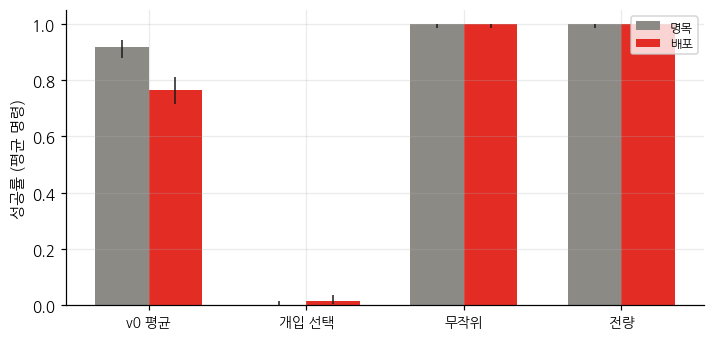

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ks = list(ROW)
x = np.arange(len(ks))
w = .34
for i, (c, col) in enumerate((("명목", GREY), ("배포", RED))):
    v = [RES[(k, c)][0] / RES[(k, c)][1] for k in ks]
    lo = [max(v[j] - wilson(*RES[(k, c)])[0], 0.)
          for j, k in enumerate(ks)]
    hi = [max(wilson(*RES[(k, c)])[1] - v[j], 0.)
          for j, k in enumerate(ks)]
    ax.bar(x + (i - .5) * w, v, w, yerr=[lo, hi], color=col,
           label=c, error_kw=dict(lw=1, ecolor=INK))
ax.set_xticks(x)
ax.set_xticklabels(ks, fontsize=9)
ax.set_ylabel("성공률 (평균 명령)")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 어려운 순간만 배우면 그 순간에 닿지 못한다

표가 예상을 뒤집었다. **무작위로 고른 9,900 스텝이 1.00 을 냈고, 게이트가 고른 같은 개수가 0.01 을 냈다.**

숫자를 의심하기 전에 무엇을 시킨 것인지 다시 본다. 게이트가 고른 상위 10% 는 **궤적의 좁은 조각**이다. 밀대가 블록을 놓쳤거나, 엉뚱한 쪽에 가 있거나, 목표를 지나친 순간들이다. 그 조각에서만 전문가를 흉내 낸 정책은 **판의 나머지 90% 에서 무엇을 해야 하는지 배우지 못했다.**

그리고 그 90% 가 먼저 온다. 출발선에서 무엇을 할지 모르면 어려운 순간에 도달하지도 못한다. 7장에서 증류가 실패한 이유로 적은 분포 이동이 여기서 다시 나온다 — 다만 이번에는 **우리가 직접 데이터를 좁혀서** 만들었다.

## 예산을 훑는다

한 점만 보고 결론을 내지 않는다. 예산을 바꿔 가며 두 선택 방식을 같은 축에 놓는다. 배포 조건만 잰다.

In [13]:
FRAC = (.005, .02, .05, .20, 1.0)
rng = np.random.default_rng(1)
CURVE = {"개입 선택": [], "무작위": []}
t0 = time.time()
for f in FRAC:
    b = max(int(len(FO) * f), 256)
    for kind in CURVE:
        idx = (ord_g[:b] if kind == "개입 선택"
               else rng.choice(len(FO), b, replace=False))
        ok, done = score(mean_act(finetune(idx)), "배포")
        CURVE[kind].append(ok / done)
    print(f"  {f * 100:.1f}% 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("예산", 9) + pad("스텝", 10, True)
      + pad("개입 선택", 12, True) + pad("무작위", 12, True))
for i, f in enumerate(FRAC):
    print(pad(f"{f * 100:.1f}%", 9)
          + pad(f"{max(int(len(FO) * f), 256):,}", 10, True)
          + pad(f"{CURVE['개입 선택'][i]:.2f}", 12, True)
          + pad(f"{CURVE['무작위'][i]:.2f}", 12, True))

  0.5% 끝  (20s)


  2.0% 끝  (40s)


  5.0% 끝  (60s)


  20.0% 끝  (79s)


  100.0% 끝  (98s)

예산           스텝   개입 선택      무작위
0.5%            495        0.08        0.20
2.0%          1,980        0.00        0.92
5.0%          4,950        0.11        1.00
20.0%        19,800        0.00        1.00
100.0%       99,000        1.00        1.00


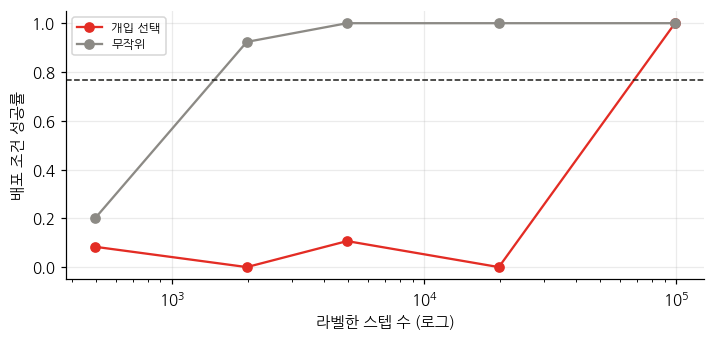

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
xs = [max(int(len(FO) * f), 256) for f in FRAC]
for kind, col in (("개입 선택", RED), ("무작위", GREY)):
    ax.plot(xs, CURVE[kind], "-o", color=col, label=kind)
v0r = RES[("v0 평균", "배포")]
ax.axhline(v0r[0] / v0r[1], ls="--", lw=1, color=INK)
ax.set_xscale("log")
ax.set_xlabel("라벨한 스텝 수 (로그)")
ax.set_ylabel("배포 조건 성공률")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

곡선 전체가 같은 말을 한다. 개입 선택은 예산이 100% 가 되어 **무작위와 같아질 때에야** 올라온다. 그전까지는 어느 예산에서도 바닥이다.

## 섞으면 달라지는가

지금까지의 표는 「개입 선택을 버리라」고 말하는 것처럼 보인다. 그렇게 결론 내기 전에 한 가지를 더 잰다. **단독으로 쓰지 않고 섞으면** 어떤가.

총 라벨 수를 맞춰 놓고 셋을 비교한다 — 전부 무작위, 반은 무작위 반은 개입, 전부 개입이다. 무작위가 아직 천장에 닿지 않은 작은 예산에서 본다.

In [15]:
def build(kind, total, rng):
    if kind == "무작위":
        return rng.choice(len(FO), total, replace=False)
    if kind == "개입만":
        return ord_g[:total]
    h = total // 2
    r = rng.choice(len(FO), h, replace=False)
    return np.concatenate([ord_g[:h], r])


KINDS = ("무작위", "반반 섞기", "개입만")
rng = np.random.default_rng(5)
t0 = time.time()
print(pad("총 라벨", 10) + "".join(pad(k, 12, True) for k in KINDS))
for total in (600, 1200, 2400):
    row = pad(f"{total:,}", 10)
    for kind in KINDS:
        net = finetune(build(kind, total, rng))
        ok, done = score(mean_act(net), "배포")
        row += pad(f"{ok / done:.2f}", 12, True)
    print(row)
print()
print(f"배포 조건 · 조건마다 300 판  ({time.time() - t0:.0f}s)")

총 라벨         무작위   반반 섞기      개입만


600               0.05        0.42        0.17


1,200             1.00        1.00        0.00


2,400             0.90        0.99        0.00

배포 조건 · 조건마다 300 판  (86s)


## 정리

**현장 데이터는 정책을 고친다.** 배포 조건에서 모은 전문가 라벨로 행동 복제를 하면 v0 의 0.77 이 1.00 이 된다. 플라이휠의 첫 바퀴가 실제로 돈다.

**그리고 전문가 자신보다 나아진다.** 대본 제어기는 배포 조건에서 0.90 인데 그것을 복제한 정책이 1.00 이다. 전문가는 참 상태를 보고 명령을 내지만 복제는 **편향된 관측에서 그 명령을 재현하도록** 배운다. 현장 데이터의 값이 명령에만 있는 것이 아니라 **그 명령이 나온 조건**에도 있다는 뜻이다.

**어려운 순간만 골라 라벨하면 실패한다.** 이 장이 확인하려던 가설의 반대가 나왔다. 게이트가 고른 상위 10% 로 배운 정책은 0.01 이고, 같은 개수를 무작위로 고르면 1.00 이다. 좁은 조각에서만 배운 정책은 **그 조각에 도달하는 법**을 배우지 못한다.

**개입 데이터는 기본 데이터와 섞어야 한다.** 총 라벨 600 개에서 무작위 0.05, 반반 섞기 0.42, 개입만 0.17 이었다. 다만 이 표는 조건마다 시드 하나씩이고 요동이 크니 값 하나를 믿지 말고 열의 경향을 읽는다 — **개입만 열은 언제나 바닥이고, 반반 열은 두 작은 예산에서 무작위보다 낫다.** 상호작용 모방학습이 개입 기록을 원래 데이터에 **더해서** 쓰는 이유가 이것이다.

**이 실습은 전문가를 너무 후하게 줬다.** 여기서 라벨은 어느 스텝에서나 즉시, 공짜로, 잡음 없이 나온다. 실기의 원격 조작은 늦게 오고, 흔들리고, 사람마다 다르다. 1.00 을 현장 기대치로 옮기면 안 된다.

**그리고 이것은 한 바퀴다.** Sirius-Fleet 의 +45% 는 3라운드에 걸친 값이고, 라운드마다 정책이 바뀌면 게이트가 고르는 순간도 바뀐다. 그 되먹임은 이 실습이 다루지 않았다.

다음 장은 플라이휠이 돌 때 **잃는 것**을 본다.